In [7]:
%pip install matplotlib 

In [5]:
%pip install matplotlib numpy
import numpy as np
import matplotlib.pyplot as plt


In [6]:
word_embeddings = {
    "cat":[0.8,0.6],
    "kitten":[0.75,0.65],
    "puppy":[0.65,0.35],
    "dog":[0.7,0.3],
    "car":[-0.5,0.2],
    "truck":[-0.45,0.15]
}


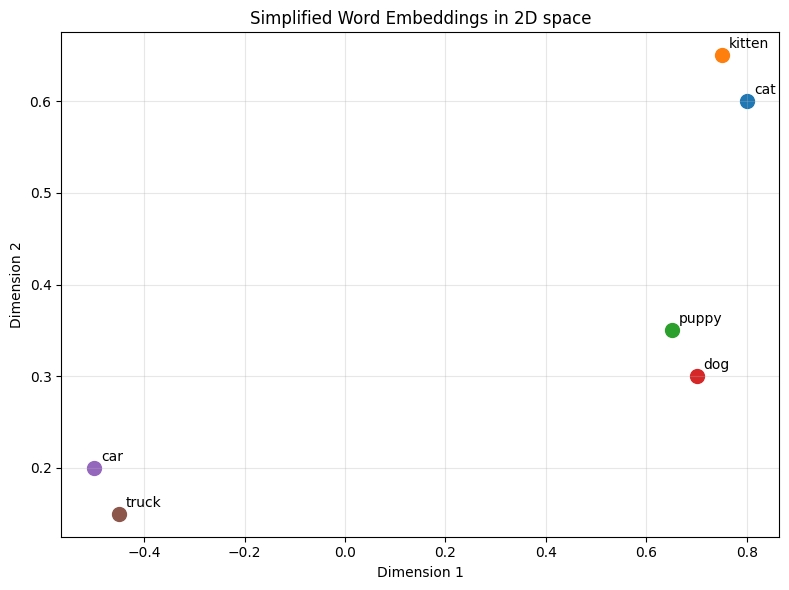

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1],s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5,5), textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D space')
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()





In [8]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product / (norm_a * norm_b)

In [11]:
cat_vector=[0.8,0.6,0.3]
kitten_vector=[0.75,0.65,0.35]
car_vector=[-0.5,0.2,0.1]
cat_kitten_siilarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_siilarity)

0.9966186334192181


In [12]:
cat_vector=[0.8,0.6,0.3]
kitten_vector=[0.75,0.65,0.35]
car_vector=[-0.5,0.2,0.1]
cat_kitten_siilarity=cosine_similarity(cat_vector,car_vector)
print(cat_kitten_siilarity)

-0.43718588548916804


In [13]:
#Huggingface Embeddings
!pip install langchain-huggingface

In [14]:
!pip install sentence-transformers

In [15]:
#Huggingface Embeddings models
from langchain_huggingface import HuggingFaceEmbeddings
#initialize a simple embedding model and no API key needed
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [17]:
text="Hello, I am learning about embeddings."
embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length: {len(embedding) }")
print(embedding)


Text: Hello, I am learning about embeddings.
Embedding length: 384
[-0.023014286532998085, -0.1026478111743927, -0.00010352343815611675, 0.0037934230640530586, 0.015323282219469547, 0.04926801472902298, -0.012406925670802593, 0.01389989536255598, 0.03878532722592354, -0.023891102522611618, 0.02676159329712391, 0.08163344860076904, 0.0413031205534935, 0.022510940209031105, -0.026447514072060585, 0.016060296446084976, 0.04206309840083122, 0.07388661056756973, -0.06676707416772842, -0.0010624374262988567, -0.026253504678606987, -0.04237829148769379, 0.02906075119972229, -0.09618093818426132, 0.037492040544748306, -0.030485277995467186, -0.03129848092794418, 0.053150713443756104, 0.0971641018986702, -0.07011301815509796, 0.022248145192861557, -0.023143688216805458, -0.02078200876712799, 0.06618607044219971, -0.05602778121829033, 0.1268676221370697, 0.034232910722494125, -0.003178562503308058, -0.07056888192892075, -0.007944546639919281, 0.034179963171482086, 0.039743922650814056, -0.027724

In [ ]:
sentences=[
    "This is sample1 sentence",
    "This is sample2 sentence",
    This is sample3 sentence",
    "This is sample4 sentence"  
]
embedding_sentence=embeddings.embed_documents(sentences)
print(f"Number of sentences: {len(embedding_sentence)}")
print(embedding_sentence)



In [19]:
from sentence_transformers import SentenceTransformer
sentences = ["This is an example sentence", "Each sentence is converted"]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embedSent = model.encode(sentences)
print(f"Length of embedSent: {len(embedSent)}")
print(embedSent)


Length of embedSent: 2
[[ 6.76569194e-02  6.34959713e-02  4.87131476e-02  7.93049783e-02
   3.74480933e-02  2.65277131e-03  3.93749513e-02 -7.09846430e-03
   5.93614057e-02  3.15369777e-02  6.00981042e-02 -5.29052615e-02
   4.06067781e-02 -2.59308387e-02  2.98428647e-02  1.12688600e-03
   7.35148042e-02 -5.03817983e-02 -1.22386612e-01  2.37028562e-02
   2.97265332e-02  4.24768738e-02  2.56337579e-02  1.99516211e-03
  -5.69190793e-02 -2.71598026e-02 -3.29035036e-02  6.60248846e-02
   1.19007230e-01 -4.58791181e-02 -7.26214051e-02 -3.25840116e-02
   5.23413308e-02  4.50553037e-02  8.25298298e-03  3.67024504e-02
  -1.39415674e-02  6.53918684e-02 -2.64271945e-02  2.06370896e-04
  -1.36643145e-02 -3.62810642e-02 -1.95043720e-02 -2.89738011e-02
   3.94270122e-02 -8.84091184e-02  2.62427772e-03  1.36713730e-02
   4.83062901e-02 -3.11566498e-02 -1.17329173e-01 -5.11690713e-02
  -8.85288343e-02 -2.18963325e-02  1.42986095e-02  4.44167666e-02
  -1.34815648e-02  7.43392259e-02  2.66382862e-02 -1.